# E-Commerce Purchase Behavior Analysis — 01 Exploratory Data Analysis

An **EDA / visualization** project: how Brazilians shop online — 99,441 Olist marketplace orders with price, freight, payment method, installments, delivery status, and review score. This notebook covers the data overview — shape, types, missing values, and univariate distributions that frame the deeper analysis in notebook 02.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils

df=utils.load_data()
print('shape:',df.shape)
df.head()

shape: (99441, 15)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,n_items,price,freight,payment,installments,payment_type,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,29.99,8.72,38.71,1.0,credit_card,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,118.70,22.76,141.46,1.0,boleto,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,159.90,19.22,179.12,3.0,credit_card,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,45.00,27.20,72.20,1.0,credit_card,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,19.90,8.72,28.62,1.0,credit_card,5.0


## 1. Structure & dtypes

In [2]:
print(df.dtypes.value_counts().to_dict())
df.info()

{dtype('O'): 9, dtype('float64'): 6}
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99441 non-null  object 
 1   customer_id                    99441 non-null  object 
 2   order_status                   99441 non-null  object 
 3   order_purchase_timestamp       99441 non-null  object 
 4   order_approved_at              99281 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  99441 non-null  object 
 8   n_items                        98666 non-null  float64
 9   price                          98666 non-null  float64
 10  freight                        98666 non-null  float64
 11  payment                        99440 non-null  float64
 12  installme

## 2. Missing values

In [3]:
mr=utils.missing_report(df)
print('columns with missing values:',len(mr))
print(mr.head(10).to_string())

columns with missing values: 10
                               missing   pct
order_delivered_customer_date     2965  2.98
order_delivered_carrier_date      1783  1.79
n_items                            775  0.78
price                              775  0.78
freight                            775  0.78
review_score                       768  0.77
order_approved_at                  160  0.16
payment                              1  0.00
installments                         1  0.00
payment_type                         1  0.00


## 3. Numeric distributions

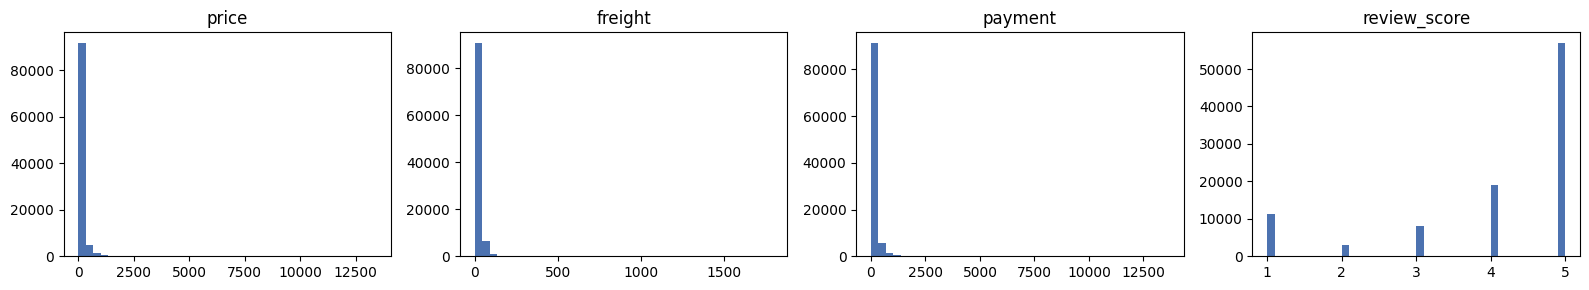

,price,freight,payment,review_score
count,98666.00,98666.00,99440.00,98673.00
mean,137.75,22.87,160.99,4.09
std,210.65,21.83,221.95,1.35
min,0.85,0.00,0.00,1.00
25%,45.90,13.85,62.01,4.00
50%,86.90,17.18,105.29,5.00
75%,149.90,24.06,176.97,5.00
max,13440.00,1794.96,13664.08,5.00


In [4]:
num=['price', 'freight', 'payment', 'review_score']
num=[c for c in num if c in df.columns]
fig,ax=plt.subplots(1,len(num),figsize=(4*len(num),3))
ax=np.atleast_1d(ax)
for a,c in zip(ax,num):
    a.hist(df[c].dropna(),bins=40,color='#4c72b0'); a.set_title(c)
plt.tight_layout(); plt.show()
df[num].describe().round(2)

## 4. Top categories

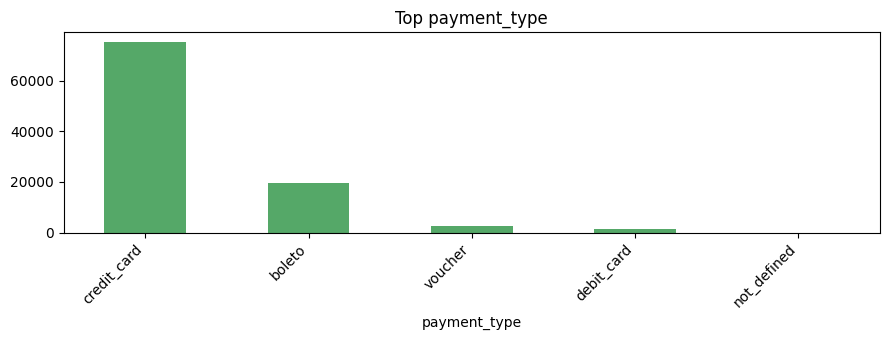

payment_type
credit_card    75387
boleto         19784
voucher         2739
debit_card      1527
not_defined        3


In [5]:
vc=utils.top_counts(df['payment_type'],10)
fig,ax=plt.subplots(figsize=(9,3.5)); vc.plot(kind='bar',ax=ax,color='#55a868'); ax.set_title('Top payment_type'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()
print(vc.to_string())

## 5. Summary

The overview above frames the domain questions answered in notebook **02 — Analysis**, where the real insights and the headline numbers (reported in the README) come from.